In [321]:
import pandas as pd

# Load CSVs
qa_df = pd.read_csv(r'C:\Users\pdm\Desktop\samadrita\Agro\AgroData\query_answer.csv')
intent_df = pd.read_csv(r'C:\Users\pdm\Desktop\samadrita\Agro\AgroData\query_intent.csv')

print(qa_df.head())
print(intent_df.head())

                                               query  \
0  asking about the control measure for aphid inf...   
1  asking about the control measure of flower dro...   
2  asking about how to avail kisan credit card lo...   
3      asking about source of early ahu rice variety   
4  asking that he has not got proper friut from h...   

                                             answers  
0  suggested him to spray rogor@2ml/lit.at evenin...  
1  suggested him to apply fertilizer in recommend...  
2  suggested to consult with officer-marketing an...  
3  suggested to take early ahu rice variety from ...  
4  suggested him to aplly recommended fertilizer ...  
                                               query        intent
0  asking about the measurement required in prepa...  1. Soil Data
1          asking about the soil condition of citrus  1. Soil Data
2  asking about the source of training of vermico...  1. Soil Data
3                         asking about soil testing.  1. Soil Dat

In [322]:
print("Intent DF Columns:", intent_df.columns)
print("QA DF Columns:", qa_df.columns)


Intent DF Columns: Index(['query', 'intent'], dtype='object')
QA DF Columns: Index(['query', 'answers'], dtype='object')


In [323]:
!pip install nltk
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pdm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pdm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

WordNet is a large lexical database of English.

Words are grouped into sets of synonyms called synsets.

Each synset represents one concept.

Synsets include definitions and example sentences.

It captures semantic relationships like:

Synonyms (similar meaning)

Antonyms (opposites)

Hypernyms (general terms, e.g., "animal" for "dog")

Hyponyms (specific terms, e.g., "dog" for "animal")

Meronyms (part-of, e.g., "wheel" for "car")

Holonyms (whole-of, e.g., "car" for "wheel")

Commonly used in NLP, linguistics, and AI applications.

Stopwords are common words in a language (e.g., the, is, in, and).

They are often filtered out during text preprocessing in NLP.

Reason: They don't carry significant meaning for tasks like classification or search.

Examples: a, an, the, in, on, at, is, are, was, were, of, to.

Removing stopwords helps reduce noise and improve model performance.

Lists of stopwords are available in libraries like NLTK, spaCy, and Scikit-learn.

Stopword removal is optional—some tasks may require keeping them (e.g., sentiment analysis).



**CLEANING THE DATA**

In [324]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [325]:
intent_df['clean_query'] = intent_df['query'].apply(clean_text)
qa_df['clean_query'] = qa_df['query'].apply(clean_text)

intent_df.head()

,query,intent,clean_query
0,asking about the measurement required in prepa...,1. Soil Data,asking measurement required preparation vermic...
1,asking about the soil condition of citrus,1. Soil Data,asking soil condition citrus
2,asking about the source of training of vermico...,1. Soil Data,asking source training vermicompost
3,asking about soil testing.,1. Soil Data,asking soil testing
4,asking for the soil testing process,1. Soil Data,asking soil testing process


TRANSLATION (FROM LOCAL LANGUAGE TO ENGLISH)

In [326]:
!pip install deep-translator

from deep_translator import GoogleTranslator

def translate_to_english(text):
    try:
        return GoogleTranslator(source='auto', target='en').translate(text)
    except:
        return text

TRANSLATE TO ENGLISH , IF NEEDED (more steps) !

In [327]:
data_path = '.'  # current directory
intent_df.to_csv(f'{data_path}/cleaned_query_intent.csv', index=False)
qa_df.to_csv(f'{data_path}/cleaned_query_answer.csv', index=False)

In [328]:
intent_df['intent'].value_counts()

intent
15. Agrochemical                     89729
4. Crop Health                       29866
8. Extension & Advisory              12794
17. Invasive Species, Weed, Pests     6006
9. Genomic & Phenotypic Trait         4705
10. Market & Economic                 4175
19. Policy & Legalities               3089
3. Crop Yield                         1503
16. Seed & Germplasm                   766
1. Soil Data                           740
14. Irrigation                         507
2. Weather & Climate                   482
5. Farm Machinery & Equipment          443
13. Supply-chain & Logistics           156
18. Environmental Impact                43
20. Farmer Data                         10
6. Socio-economic & Demographic          8
11. IoT & Sensor                         1
Name: count, dtype: int64

In [329]:
intent_df[['query', 'clean_query', 'intent']].sample(5)


,query,clean_query,intent
40152,asking about the controle of ret in sugercane ...,asking controle ret sugercane fild,15. Agrochemical
123433,control measures of leaf curl disease,control measure leaf curl disease,4. Crop Health
117530,asking about control of blight in potato,asking control blight potato,4. Crop Health
150718,asking about some variety of okra.,asking variety okra,9. Genomic & Phenotypic Trait
102274,asked about whether tomorrow the installment f...,asked whether tomorrow installment pm kisan re...,19. Policy & Legalities


*✔ PHASE 2 : INTENT CLASSIFIER *

In [330]:
#! pip install transformers==4.41.1 sentence-transformers==2.2.2 faiss-cpu datasets accelerate

In [331]:
!pip install transformers==4.41.1


  Using cached transformers-4.41.1-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.41.1-py3-none-any.whl (9.1 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 4.41.2
    Uninstalling transformers-4.41.2:
      Successfully uninstalled transformers-4.41.2


In [332]:
!pip install sentence-transformers==2.2.2

  Using cached sentence_transformers-2.2.2-py3-none-any.whl
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.0.0
    Uninstalling sentence-transformers-5.0.0:
      Successfully uninstalled sentence-transformers-5.0.0


In [333]:
!pip install faiss-cpu

In [334]:
!pip install datasets

In [335]:
!pip install accelerate

In [336]:
!pip install --upgrade pip

In [337]:
import pandas as pd

# Load the cleaned dataset
data_path = '.' 
df = pd.read_csv(r'C:\Users\pdm\Desktop\samadrita\Agro\cleaned_query_intent.csv')

# Inspect
df.head()

,query,intent,clean_query
0,asking about the measurement required in prepa...,1. Soil Data,asking measurement required preparation vermic...
1,asking about the soil condition of citrus,1. Soil Data,asking soil condition citrus
2,asking about the source of training of vermico...,1. Soil Data,asking source training vermicompost
3,asking about soil testing.,1. Soil Data,asking soil testing
4,asking for the soil testing process,1. Soil Data,asking soil testing process


In [338]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['intent'])

# Save this encoder for future use
import joblib
joblib.dump(label_encoder, f'{data_path}/intent_label_encoder.pkl')

num_labels = df['label'].nunique()
print("Unique intents:", num_labels)

Unique intents: 18


LabelEncoder() converts categorical intents (e.g., crop_disease, weather_info) into numerical labels.

fit_transform() assigns a unique integer to each intent.

The encoder is saved using joblib for future use (e.g., during prediction).

nunique() counts the number of unique intent classes.

This prepares the intent column for use in machine learning models.

In [339]:
# TRAIN - TEST SPLIT
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_query'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42)


In [340]:
#TOKENIZE WITH DistilBERT
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)


DistilBertTokenizerFast loads a pre-trained DistilBERT tokenizer.

tokenizer(...) converts train_texts and val_texts into token IDs that the DistilBERT model can understand.

truncation=True ensures texts are cut off if too long.

padding=True ensures all sequences are the same length.

This step prepares the text data for input into the DistilBERT model.

In [341]:
#CREATE DATASET CLASS
import torch

class IntentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.encodings['input_ids'][idx]),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx]),
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

train_dataset = IntentDataset(train_encodings, train_labels)
val_dataset = IntentDataset(val_encodings, val_labels)


A custom PyTorch Dataset class IntentDataset is created.

It stores tokenized text (encodings) and their labels.

getitem returns a dictionary with input_ids, attention_mask, and labels as tensors.

len gives the dataset size.

train_dataset and val_dataset are created for use in model training and validation.

What is meant by creating a Dataset class? In PyTorch, creating a custom Dataset class means:

You define how data should be accessed and returned to the model during training.

It helps PyTorch understand how to get one sample at a time from your dataset.

Why create a Dataset class? PyTorch models don’t use raw lists or arrays directly.

You need to wrap your data in a class that extends torch.utils.data.Dataset.

It must implement: init() → Load and store the data.

getitem(index) → Return one sample (e.g., input and label) at a time.

len() → Return the total number of samples.

In short: Creating a Dataset class is how you prepare your data to work with PyTorch’s DataLoader for efficient batching, shuffling, and training.

In [342]:
#DEFINE THE MODEL
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=num_labels)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [343]:
import transformers
print(transformers.__version__)


4.41.1


In [344]:
# Removed the upgrade command as specific versions are being installed
# !pip install --upgrade peft # Try upgrading peft to a newer version
pass

In [345]:
import torch
print("PyTorch version:", torch.__version__)
print("Built with CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
 # Should print True to check if hardware accelerator is set to gpu

PyTorch version: 2.5.1+cu121
Built with CUDA: 12.1
CUDA available: True


In [346]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU name:", torch.cuda.get_device_name(0))


CUDA available: True
CUDA version: 12.1
GPU name: NVIDIA GeForce RTX 3090 Ti


In [347]:
import sys
print(sys.executable)


C:\Users\pdm\Desktop\samadrita\.venv\Scripts\python.exe


In [348]:
import sys
print(sys.executable)


C:\Users\pdm\Desktop\samadrita\.venv\Scripts\python.exe


In [349]:
pip install transformers==4.41.2 --upgrade

  Using cached transformers-4.41.2-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.41.2-py3-none-any.whl (9.1 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 4.41.1
    Uninstalling transformers-4.41.1:
      Successfully uninstalled transformers-4.41.1
Note: you may need to restart the kernel to use updated packages.


In [350]:
pip install peft==0.10.0 --upgrade

Note: you may need to restart the kernel to use updated packages.


In [351]:
import transformers
import peft
import sys

print("Transformers version:", transformers.__version__)
print("PEFT version:", peft.__version__)
print("Python executable:", sys.executable)


Transformers version: 4.41.1
PEFT version: 0.10.0
Python executable: C:\Users\pdm\Desktop\samadrita\.venv\Scripts\python.exe


In [352]:
#import transformers
import peft
print("PEFT version:", peft.__version__)


PEFT version: 0.10.0


In [353]:
# TRAIN WITH HUGGING FACE TRAINER

from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    save_strategy="epoch",                 #  Save model at the end of every epoch
    save_total_limit=2,                    #  Optional: keep only last 2 checkpoints to save space
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

#trainer.train()


C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [354]:

#trainer.save_model("./results/final_model")
#tokenizer.save_pretrained("./results/final_model")


In [355]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("./results/final_model")
tokenizer = AutoTokenizer.from_pretrained("./results/final_model")


In [356]:
from sklearn.preprocessing import LabelEncoder
import joblib

label_encoder = joblib.load(r"C:\Users\pdm\Desktop\samadrita\Agro\intent_label_encoder.pkl")
print(label_encoder.classes_)  # Gives correct label order


['1. Soil Data' '10. Market & Economic' '11. IoT & Sensor'
 '13. Supply-chain & Logistics' '14. Irrigation' '15. Agrochemical'
 '16. Seed & Germplasm' '17. Invasive Species, Weed, Pests'
 '18. Environmental Impact' '19. Policy & Legalities'
 '2. Weather & Climate' '20. Farmer Data' '3. Crop Yield' '4. Crop Health'
 '5. Farm Machinery & Equipment' '6. Socio-economic & Demographic'
 '8. Extension & Advisory' '9. Genomic & Phenotypic Trait']


In [357]:
intent_labels = list(label_encoder.classes_)


In [358]:
for i, label in enumerate(intent_labels):
    print(f"LABEL_{i}: {label}")


LABEL_0: 1. Soil Data
LABEL_1: 10. Market & Economic
LABEL_2: 11. IoT & Sensor
LABEL_3: 13. Supply-chain & Logistics
LABEL_4: 14. Irrigation
LABEL_5: 15. Agrochemical
LABEL_6: 16. Seed & Germplasm
LABEL_7: 17. Invasive Species, Weed, Pests
LABEL_8: 18. Environmental Impact
LABEL_9: 19. Policy & Legalities
LABEL_10: 2. Weather & Climate
LABEL_11: 20. Farmer Data
LABEL_12: 3. Crop Yield
LABEL_13: 4. Crop Health
LABEL_14: 5. Farm Machinery & Equipment
LABEL_15: 6. Socio-economic & Demographic
LABEL_16: 8. Extension & Advisory
LABEL_17: 9. Genomic & Phenotypic Trait


In [359]:
intent_labels = [
    "1. Soil Data",                               # LABEL_0
    "10. Market & Economic",                      # LABEL_1
    "11. IoT & Sensor",                           # LABEL_2
    "13. Supply-chain & Logistics",              # LABEL_3
    "14. Irrigation",                             # LABEL_4
    "15. Agrochemical",                           # LABEL_5
    "16. Seed & Germplasm",                       # LABEL_6
    "17. Invasive Species, Weed, Pests",         # LABEL_7
    "18. Environmental Impact",                   # LABEL_8
    "19. Policy & Legalities",                    # LABEL_9
    "2. Weather & Climate",                       # LABEL_10
    "20. Farmer Data",                            # LABEL_11
    "3. Crop Yield",                              # LABEL_12
    "4. Crop Health",                             # LABEL_13
    "5. Farm Machinery & Equipment",              # LABEL_14
    "6. Socio-economic & Demographic",           # LABEL_15
    "8. Extension & Advisory",                    # LABEL_16
    "9. Genomic & Phenotypic Trait"              # LABEL_17
]


In [360]:
def predict_intent(query):
    inputs = tokenizer(query, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        logits = model(**inputs).logits
        pred_idx = torch.argmax(logits, dim=1).item()
    return intent_labels[pred_idx]


In [361]:
print(predict_intent("Which pesticide is best for tomato fruit borer?"))
# Should return: something like "15. Agrochemical"

print(predict_intent("What is the tendency of rainfall for next 2 days?"))
# Should return: "2.Weather & Climate"


15. Agrochemical
2. Weather & Climate


In [362]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("./results/final_model")


In [363]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("./results/final_model")
model.to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [364]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    recall = recall_score(labels, preds, average='weighted', zero_division=0)
    f1 = f1_score(labels, preds, average='weighted', zero_division=0)

    return {
        "accuracy": acc,
        "accuracy_percent": round(acc * 100, 2),
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [365]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("results/final_model")


In [366]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,           # reuse or redefine
    eval_dataset=val_dataset,     # your validation dataset
    compute_metrics=compute_metrics
)


***Evaluation of Hugging Face Trainer Model***

In [367]:
metrics = trainer.evaluate()
print("Evaluation Metrics:", metrics)


Evaluation Metrics: {'eval_loss': 0.1634582281112671, 'eval_accuracy': 0.9496532817287534, 'eval_accuracy_percent': 94.97, 'eval_precision': 0.9483756540783076, 'eval_recall': 0.9496532817287534, 'eval_f1': 0.9476596706972134, 'eval_runtime': 16.6048, 'eval_samples_per_second': 1867.229, 'eval_steps_per_second': 116.713}


In [368]:
def predict_intent(query):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move model to the correct device
    model.to(device)

    # Tokenize and move inputs to same device
    inputs = tokenizer(query, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        pred_idx = torch.argmax(outputs.logits, dim=1).item()

    return intent_labels[pred_idx]


In [369]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Example input to check devices
test_query = "What pesticide should I use for tomato?"
inputs = tokenizer(test_query, return_tensors="pt", truncation=True, padding=True).to(device)

# Check device alignment
print("Model is on:", next(model.parameters()).device)
print("Input is on:", inputs['input_ids'].device)


Model is on: cuda:0
Input is on: cuda:0


In [370]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

model = AutoModelForSequenceClassification.from_pretrained("./results/final_model")
tokenizer = AutoTokenizer.from_pretrained("./results/final_model")
model.eval()  # Set model to evaluation mode


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [371]:
print(predict_intent("Which pesticide is best for tomato fruit borer?"))


15. Agrochemical


In [372]:
print(label_encoder.classes_)  # Check order and class count


['1. Soil Data' '10. Market & Economic' '11. IoT & Sensor'
 '13. Supply-chain & Logistics' '14. Irrigation' '15. Agrochemical'
 '16. Seed & Germplasm' '17. Invasive Species, Weed, Pests'
 '18. Environmental Impact' '19. Policy & Legalities'
 '2. Weather & Climate' '20. Farmer Data' '3. Crop Yield' '4. Crop Health'
 '5. Farm Machinery & Equipment' '6. Socio-economic & Demographic'
 '8. Extension & Advisory' '9. Genomic & Phenotypic Trait']


In [373]:

predict_intent("Which is the best season for sowing tomato seeds ?")


'8. Extension & Advisory'

In [374]:
predict_intent("How can i increase the yield of wheat?")

'3. Crop Yield'

In [375]:
# Evaluate using the built-in Trainer method
#eval_result = trainer.evaluate()
#print("Trainer Eval Result:", eval_result)


 ✔ ***PHASE 3***

Routing Logic (Core Intelligence Engine)

In [376]:
routing_map = {
    '15. Agrochemical': 'structured_model',
    '4. Crop Health': 'rag_llm',
    '8. Extension & Advisory': 'simple_llm',
    '17. Invasive Species, Weed, Pests': 'rag_llm',
    '9. Genomic & Phenotypic Trait': 'simple_llm',
    '10. Market & Economic': 'external_api',
    '19. Policy & Legalities': 'simple_llm',
    '3. Crop Yield': 'structured_model',
    '16. Seed & Germplasm': 'simple_llm',
    '1. Soil Data': 'structured_model',
    '14. Irrigation': 'structured_model',
    '2. Weather & Climate': 'external_api',
    '5. Farm Machinery & Equipment': 'simple_llm',
    '13. Supply-chain & Logistics': 'simple_llm',
    '18. Environmental Impact': 'simple_llm',
    '20. Farmer Data': 'simple_llm',
    '6. Socio-economic & Demographic': 'simple_llm',
    '11. IoT & Sensor': 'simple_llm'
}


In [377]:
def route_query(query):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)  # Ensure model is on same device as inputs

    # Tokenize and move tensors to device
    inputs = tokenizer(query, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    predicted = torch.argmax(outputs.logits, dim=1)
    intent = label_encoder.inverse_transform(predicted.cpu().numpy())[0]  # back to CPU for label decoding

    route = routing_map.get(intent, 'simple_llm')

    return {
        'query': query,
        'predicted_intent': intent,
        'route': route
    }


In [378]:
route_query("WhAT IS  the soil condition of citrus?")

{'query': 'WhAT IS  the soil condition of citrus?',
 'predicted_intent': '1. Soil Data',
 'route': 'structured_model'}

In [379]:
unique_routes = set(routing_map.values())
print(unique_routes)


{'external_api', 'rag_llm', 'structured_model', 'simple_llm'}


In [380]:
def handle_rag_llm(query):
    return "Answer from RAG + LLM (to be implemented)"

def handle_structured_model(query, predicted_intent):
    return "Answer from Structured ML model (to be implemented)"

def handle_external_api(query, predicted_intent):
    return "Answer from External API (to be implemented)"

def handle_simple_llm(query):
    return "Answer from Simple LLM (to be implemented)"


In [381]:
def agro_advisor_routing(query):
    result = route_query(query)
    intent = result['predicted_intent']
    route = result['route']

    return {
        'query': query,
        'intent': intent,
        'module': route
    }


In [382]:
agro_advisor_routing("Why is my paddy turning brown?")

{'query': 'Why is my paddy turning brown?',
 'intent': '15. Agrochemical',
 'module': 'structured_model'}

In [383]:
queries = [
    "Will it rain today?",
    "What is the market price for rice?",
    "How to prevent leaf curling in tomatoes?",
    "Which crop is best for my soil?",
]

for q in queries:
    print(agro_advisor_routing(q))
    print("="*60)


{'query': 'Will it rain today?', 'intent': '2. Weather & Climate', 'module': 'external_api'}
{'query': 'What is the market price for rice?', 'intent': '10. Market & Economic', 'module': 'external_api'}
{'query': 'How to prevent leaf curling in tomatoes?', 'intent': '15. Agrochemical', 'module': 'structured_model'}
{'query': 'Which crop is best for my soil?', 'intent': '15. Agrochemical', 'module': 'structured_model'}


✔ ***PHASE 4***

In [384]:
!pip install pdfplumber sentence-transformers faiss-cpu --quiet


In [385]:
!pip install sentence-transformers faiss-cpu openai --quiet


In [386]:
import pandas as pd

data = [
    {
        "question": "Why is my rice turning yellow?",
        "answer": "Yellowing can be due to nitrogen deficiency or iron toxicity."
    },
    {
        "question": "What pesticide is used for aphids?",
        "answer": "Aphids can be controlled using neem oil or imidacloprid-based sprays."
    },
    {
        "question": "What causes powdery mildew in wheat?",
        "answer": "High humidity and poor airflow cause powdery mildew. Use fungicides like sulfur or triazoles."
    }
]

df = pd.DataFrame(data)
df['text'] = df['question'] + " " + df['answer']
df.head()


,question,answer,text
0,Why is my rice turning yellow?,Yellowing can be due to nitrogen deficiency or...,Why is my rice turning yellow? Yellowing can b...
1,What pesticide is used for aphids?,Aphids can be controlled using neem oil or imi...,What pesticide is used for aphids? Aphids can ...
2,What causes powdery mildew in wheat?,High humidity and poor airflow cause powdery m...,What causes powdery mildew in wheat? High humi...


In [387]:
import pandas as pd

# Load the file from Drive
expert_df = pd.read_csv(r'C:\Users\pdm\Desktop\samadrita\Agro\cleaned_query_answer.csv')
expert_df.head()

,query,answers,clean_query
0,asking about the control measure for aphid inf...,suggested him to spray rogor@2ml/lit.at evenin...,asking control measure aphid infestation musta...
1,asking about the control measure of flower dro...,suggested him to apply fertilizer in recommend...,asking control measure flower drop problem coc...
2,asking about how to avail kisan credit card lo...,suggested to consult with officer-marketing an...,asking avail kisan credit card loan sali crop
3,asking about source of early ahu rice variety,suggested to take early ahu rice variety from ...,asking source early ahu rice variety
4,asking that he has not got proper friut from h...,suggested him to aplly recommended fertilizer ...,asking got proper friut coconut plant


In [388]:
# Combine question and answer into one field
expert_df['text'] = expert_df['query'] + " " + expert_df['answers']
texts = expert_df['text'].tolist()

In [389]:
import transformers
print(transformers.__version__)


4.41.1


In [390]:
!pip install huggingface_hub==0.14.1 --upgrade

  Using cached huggingface_hub-0.14.1-py3-none-any.whl.metadata (7.6 kB)
Using cached huggingface_hub-0.14.1-py3-none-any.whl (224 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.33.4
    Uninstalling huggingface-hub-0.33.4:
      Successfully uninstalled huggingface-hub-0.33.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 1.9.0 requires huggingface_hub>=0.21.0, but you have huggingface-hub 0.14.1 which is incompatible.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.14.1 which is incompatible.
peft 0.10.0 requires huggingface-hub>=0.17.0, but you have huggingface-hub 0.14.1 which is incompatible.
tokenizers 0.19.1 requires huggingface-hub<1.0,>=0.16.4, but you have huggingface-hub 0.14.1 which is incompatible.
transformers 4.41.2 requires huggingface-hub<1.0,>=0.23.0, but you have huggingface-hub 0.14.1 which is incompatible.


In [391]:
!pip uninstall sentence-transformers huggingface_hub -y

Found existing installation: sentence-transformers 2.2.2
Uninstalling sentence-transformers-2.2.2:
  Successfully uninstalled sentence-transformers-2.2.2
Found existing installation: huggingface-hub 0.14.1
Uninstalling huggingface-hub-0.14.1:
  Successfully uninstalled huggingface-hub-0.14.1


In [392]:
!pip install --upgrade pip setuptools


In [393]:
!pip install "sentence-transformers>=2.2.2"
!pip install "huggingface-hub>=0.22.2"

  Using cached sentence_transformers-5.0.0-py3-none-any.whl.metadata (16 kB)
  Using cached huggingface_hub-0.33.4-py3-none-any.whl.metadata (14 kB)
Using cached sentence_transformers-5.0.0-py3-none-any.whl (470 kB)
Using cached huggingface_hub-0.33.4-py3-none-any.whl (515 kB)

   ---------------------------------------- 0/2 [huggingface-hub]
   ---------------------------------------- 0/2 [huggingface-hub]
   ---------------------------------------- 0/2 [huggingface-hub]
   ---------------------------------------- 0/2 [huggingface-hub]
   ---------------------------------------- 0/2 [huggingface-hub]
   ---------------------------------------- 0/2 [huggingface-hub]
   ---------------------------------------- 0/2 [huggingface-hub]
   ---------------------------------------- 0/2 [huggingface-hub]
   ---------------------------------------- 0/2 [huggingface-hub]
   ---------------------------------------- 0/2 [huggingface-hub]
   -------------------- ------------------- 1/2 [sentence-tra

In [394]:
#Generate Embeddings using MiniLM
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [395]:
# Drop rows with missing values in 'text' column
#expert_df = expert_df.dropna(subset=['text'])

# Ensure all entries are string type
#expert_df['text'] = expert_df['text'].astype(str)


import pandas as pd

expert_df = pd.read_csv(r'C:\Users\pdm\Desktop\samadrita\Agro\cleaned_query_answer.csv')  # Update with real file
# Combine question and answer into one field
expert_df['text'] = expert_df['query'] + " " + expert_df['answers']
texts = expert_df['text'].tolist()
expert_df.dropna(subset=['text'], inplace=True)
expert_df['text'] = expert_df['text'].astype(str)


In [396]:
embeddings = embedding_model.encode(expert_df['text'].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 5588/5588 [00:40<00:00, 138.27it/s]


In [397]:
import numpy as np
import pickle

# Save embeddings (if not already saved)
np.save('expert_embeddings.npy', embeddings)

# Save expert_df (which includes 'text') as pickle
expert_df.to_pickle('expert_df.pkl')


In [398]:
!pip install faiss-cpu --quiet

In [399]:
import faiss
import numpy as np
import pandas as pd
import pickle

# Load embeddings and expert_df
embeddings = np.load(r'C:\Users\pdm\Desktop\samadrita\Agro\expert_embeddings.npy')
expert_df = pd.read_pickle(r'C:\Users\pdm\Desktop\samadrita\Agro\expert_df.pkl')

# Step 1: Normalize embeddings (recommended for cosine similarity)
faiss.normalize_L2(embeddings)

# Step 2: Create FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # Inner Product = Cosine similarity after normalization
index.add(embeddings)

# Step 3: Save FAISS index
faiss.write_index(index, 'expert_faiss.index')


In [400]:
# Load SentenceTransformer separately
from sentence_transformers import SentenceTransformer
retriever_model = SentenceTransformer('all-MiniLM-L6-v2')

def retrieve_answers(query, top_k=3):
    # Embed the query
    query_embedding = retriever_model.encode([query])
    faiss.normalize_L2(query_embedding)
    
    # Search in FAISS index
    D, I = index.search(query_embedding, top_k)
    results = expert_df.iloc[I[0]]['text'].tolist()
    
    return results


C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [401]:
retrieve_answers("What pesticide should I use for tomato?")


['asking about pest control in tomato. suggested to mix 2 ml malathion 50ec/liter of water and then spray.',
 'asking about use of bio-pesticide in tomato field explained in details',
 'pest control in tomato adviced to spray rogor @ 2ml/l of water']

In [402]:
!pip install openai


In [403]:
import openai

client = openai.OpenAI(api_key="your api key")

# List available models for your account
models = client.models.list()

for model in models.data:
    print(model.id)


text-embedding-ada-002
whisper-1
gpt-3.5-turbo
tts-1
gpt-3.5-turbo-16k
davinci-002
babbage-002
gpt-3.5-turbo-instruct
gpt-3.5-turbo-instruct-0914
dall-e-3
dall-e-2
gpt-3.5-turbo-1106
tts-1-hd
tts-1-1106
tts-1-hd-1106
text-embedding-3-small
text-embedding-3-large
gpt-3.5-turbo-0125
gpt-4o
gpt-4o-2024-05-13
gpt-4o-mini-2024-07-18
gpt-4o-mini
gpt-4o-2024-08-06
o1-preview-2024-09-12
o1-preview
o1-mini-2024-09-12
o1-mini
gpt-4o-audio-preview-2024-10-01
gpt-4o-audio-preview
omni-moderation-latest
omni-moderation-2024-09-26
gpt-4o-audio-preview-2024-12-17
gpt-4o-mini-audio-preview-2024-12-17
gpt-4o-mini-audio-preview
gpt-4o-2024-11-20
gpt-4o-search-preview-2025-03-11
gpt-4o-search-preview
gpt-4o-mini-search-preview-2025-03-11
gpt-4o-mini-search-preview
gpt-4o-transcribe
gpt-4o-mini-transcribe
gpt-4o-mini-tts
gpt-4.1-2025-04-14
gpt-4.1
gpt-4.1-mini-2025-04-14
gpt-4.1-mini
gpt-4.1-nano-2025-04-14
gpt-4.1-nano
gpt-image-1
gpt-4o-audio-preview-2025-06-03


In [404]:
def embed_texts(texts):
    response = client.embeddings.create(
        model="gpt-3.5-turbo",  # or "text-embedding-3-large"
        input=texts
    )
    return [e.embedding for e in response.data]


In [485]:
def generate_rag_answer(query, retrieved_chunks):
    prompt = f"""
You are a farming expert.

Farmer question: "{query}"

Relevant expert advice:
- {retrieved_chunks[0]}
- {retrieved_chunks[1]}
- {retrieved_chunks[2]}

Give a 2-point recommendation in simple explainable language and relevant to the context and accurate for the query asked.
"""
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.5
    )
    return response.choices[0].message.content

In [406]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

model = AutoModelForSequenceClassification.from_pretrained("./results/final_model")
tokenizer = AutoTokenizer.from_pretrained("./results/final_model")

In [484]:
predict_intent("What is the current market price of potatoes?")

'10. Market & Economic'

In [412]:
model_path = r"C:\Users\pdm\Desktop\samadrita\Agro\results\final_model"


In [414]:
# Example feedback function
def collect_feedback(query, intent, answer, rating):
    feedback = {
        "query": query,
        "predicted_intent": intent,
        "suggested_answer": answer,
        "user_rating": rating  # scale 1–5
    }
    # Save to a feedback file
    feedback_df = pd.DataFrame([feedback])
    feedback_df.to_csv("feedback_log.csv", mode='a', header=False, index=False)


PHASE 5

MODEL FOR CROP RECOMMENDATION

In [415]:
import pandas as pd

crop_rec_df = pd.read_csv(r'C:\Users\pdm\Desktop\samadrita\Agro\AgroData\Crop_recommendation.csv')
crop_rec_df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [416]:
!pip install xgboost


In [417]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib


In [418]:
label_encoder = LabelEncoder()
crop_rec_df['label_encoded'] = label_encoder.fit_transform(crop_rec_df['label'])


In [419]:
X = crop_rec_df.drop(['label', 'label_encoded'], axis=1)
y = crop_rec_df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [420]:
modelxg = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
modelxg.fit(X_train, y_train)


C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:47:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [421]:
y_pred = modelxg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Accuracy:", f"{acc * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.9863636363636363
Accuracy: 98.64%
Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.96      0.96      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       0.95      1.00      0.97        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange

In [422]:
joblib.dump(modelxg, "xgb_crop_model.pkl")
joblib.dump(label_encoder, "crop_label_encoder.pkl")

['crop_label_encoder.pkl']

In [423]:
# Example input: [N, P, K, temperature, humidity, ph, rainfall]
sample_input = [[90, 42, 43, 20.87, 82.0, 6.5, 202.9]]

# Predict
pred = modelxg.predict(sample_input)
pred_crop = label_encoder.inverse_transform(pred)
print("Recommended Crop:", pred_crop[0])

Recommended Crop: rice


MODEL FOR CROP YIELD

In [424]:
#Import & Load the Data
import pandas as pd

crop_prod_df = pd.read_csv(r'C:\Users\pdm\Desktop\samadrita\Agro\AgroData\crop_production.csv')
crop_prod_df.head()


,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75


In [425]:
#Basic Cleanup
crop_prod_df = crop_prod_df.dropna()

# Optional: clean whitespace column names
crop_prod_df.columns = [col.strip() for col in crop_prod_df.columns]

# Remove 0s from numerical fields
crop_prod_df = crop_prod_df[(crop_prod_df['Area'] > 0) & (crop_prod_df['Production'] > 0) & (crop_prod_df['Yield'] > 0)]


In [426]:
#Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

cat_cols = ['State', 'District', 'Crop', 'Season']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    crop_prod_df[col] = le.fit_transform(crop_prod_df[col])
    label_encoders[col] = le


In [427]:
#feature target split
X = crop_prod_df[['State', 'District', 'Crop', 'Season', 'Area', 'Production', 'Crop_Year']]
y = crop_prod_df['Yield']  # Yield is in Tonnes/Hectare


In [428]:
#train -test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [429]:
#train XG Boost 
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

modelxgb = XGBRegressor()
modelxgb.fit(X_train, y_train)

y_pred = modelxgb.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred))) #value range (0 to 40,000+)
print("R² Score:", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

accuracy_percent = r2 * 100
print(f"Model Accuracy: {accuracy_percent:.2f}%")


RMSE: 229.83672299687763
R² Score: 0.9399093822810325
Model Accuracy: 93.99%


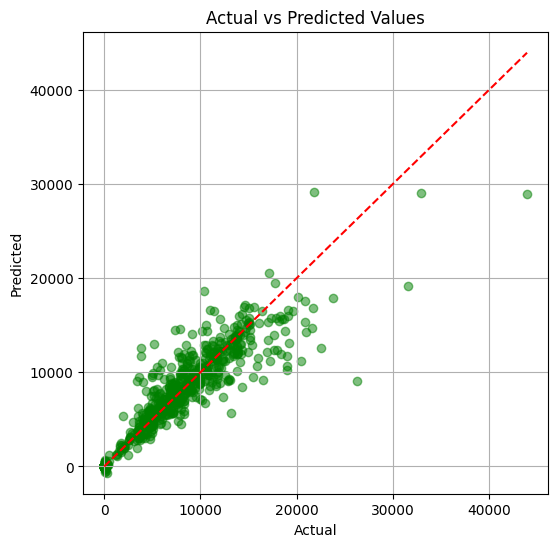

In [430]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.grid(True)
plt.show()


In [431]:
#save the model
import joblib

joblib.dump(modelxgb, 'crop_yield_model.pkl')
joblib.dump(label_encoders, 'yield_label_encoders.pkl')


['yield_label_encoders.pkl']

In [432]:
import joblib

modelxgb = joblib.load("crop_yield_model.pkl")
print(type(modelxgb))


<class 'xgboost.sklearn.XGBRegressor'>


In [433]:
#example test

import joblib

# Load your saved model (trained with scikit-learn or XGBoost)
modelxgb = joblib.load("crop_yield_model.pkl")
# Sample input: [State, District, Crop, Season, Area, Production, Year]
# Predict using structured input
sample_input = [[2, 0, 5, 2, 3.0, 12.0, 2017]]  # example input
pred_yield = modelxgb.predict(sample_input)

print("Predicted Yield (Tonnes/Hectare):", pred_yield[0])

Predicted Yield (Tonnes/Hectare): 2.6198432


In [434]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the data
crop_prod_df = pd.read_csv(r"C:\Users\pdm\Desktop\samadrita\Agro\AgroData\crop_production.csv")

# Strip whitespaces from column names
crop_prod_df.columns = crop_prod_df.columns.str.strip()

# Drop rows with missing values
crop_prod_df = crop_prod_df.dropna()

# Apply LabelEncoder to Crop
le_crop = LabelEncoder()
crop_prod_df['Crop_Encoded'] = le_crop.fit_transform(crop_prod_df['Crop'])

# ✅ Now print the correct mapping: Number -> Crop Name
for i, label in enumerate(le_crop.classes_):
    print(f"{i}: {label}")


0: Arecanut
1: Arhar/Tur
2: Bajra
3: Banana
4: Barley
5: Black pepper
6: Cardamom
7: Cashewnut
8: Castor seed
9: Coconut 
10: Coriander
11: Cotton(lint)
12: Cowpea(Lobia)
13: Dry chillies
14: Garlic
15: Ginger
16: Gram
17: Groundnut
18: Guar seed
19: Horse-gram
20: Jowar
21: Jute
22: Khesari
23: Linseed
24: Maize
25: Masoor
26: Mesta
27: Moong(Green Gram)
28: Moth
29: Niger seed
30: Oilseeds total
31: Onion
32: Other  Rabi pulses
33: Other Cereals
34: Other Kharif pulses
35: Other Summer Pulses
36: Peas & beans (Pulses)
37: Potato
38: Ragi
39: Rapeseed &Mustard
40: Rice
41: Safflower
42: Sannhamp
43: Sesamum
44: Small millets
45: Soyabean
46: Sugarcane
47: Sunflower
48: Sweet potato
49: Tapioca
50: Tobacco
51: Turmeric
52: Urad
53: Wheat
54: other oilseeds


In [435]:

# Create encoders
le_state = LabelEncoder()
le_district = LabelEncoder()
le_season = LabelEncoder()

# Fit and transform
crop_prod_df['Crop_Encoded'] = le_crop.fit_transform(crop_prod_df['Crop'])
crop_prod_df['State_Encoded'] = le_state.fit_transform(crop_prod_df['State'])
crop_prod_df['District_Encoded'] = le_district.fit_transform(crop_prod_df['District'])
crop_prod_df['Season_Encoded'] = le_season.fit_transform(crop_prod_df['Season'])


In [436]:
print("State Mappings")
for i, name in enumerate(le_state.classes_):
    print(f"{i}: {name}")


State Mappings
0: Andaman and Nicobar Island
1: Andhra Pradesh
2: Arunachal Pradesh
3: Assam
4: Bihar
5: CHANDIGARH
6: Chhattisgarh
7: Dadra and Nagar Haveli
8: Daman and Diu
9: Delhi
10: Goa
11: Gujarat
12: Haryana
13: Himachal Pradesh
14: Jammu and Kashmir
15: Jharkhand
16: Karnataka
17: Kerala
18: Laddak
19: Madhya Pradesh
20: Maharashtra
21: Manipur
22: Meghalaya
23: Mizoram
24: Nagaland
25: Odisha
26: Puducherry
27: Punjab
28: Rajasthan
29: Sikkim
30: THE DADRA AND NAGAR HAVELI
31: Tamil Nadu
32: Telangana
33: Tripura
34: Uttar Pradesh
35: Uttarakhand
36: West Bengal


In [437]:
print("\n District Mappings")
for i, name in enumerate(le_district.classes_):
    print(f"{i}: {name}")



 District Mappings
0: ADILABAD
1: AGAR MALWA
2: AGRA
3: AHMADABAD
4: AHMEDNAGAR
5: AIZAWL
6: AJMER
7: AKOLA
8: ALAPPUZHA
9: ALIGARH
10: ALIPURDUAR
11: ALIRAJPUR
12: ALLAHABAD
13: ALMORA
14: ALWAR
15: AMBALA
16: AMBEDKAR NAGAR
17: AMETHI
18: AMRAVATI
19: AMRELI
20: AMRITSAR
21: AMROHA
22: ANAND
23: ANANTAPUR
24: ANANTNAG
25: ANJAW
26: ANUGUL
27: ANUPPUR
28: ARARIA
29: ARAVALLI
30: ARIYALUR
31: ARWAL
32: ASHOKNAGAR
33: AURAIYA
34: AURANGABAD
35: AZAMGARH
36: BADGAM
37: BAGALKOTE
38: BAGESHWAR
39: BAGHPAT
40: BAHRAICH
41: BAKSA
42: BALAGHAT
43: BALANGIR
44: BALESHWAR
45: BALLARI
46: BALLIA
47: BALOD
48: BALODA BAZAR
49: BALRAMPUR
50: BANAS KANTHA
51: BANDA
52: BANDIPORA
53: BANGALORE RURAL
54: BANKA
55: BANKURA
56: BANSWARA
57: BARABANKI
58: BARAMULLA
59: BARAN
60: BAREILLY
61: BARGARH
62: BARMER
63: BARNALA
64: BARPETA
65: BARWANI
66: BASTAR
67: BASTI
68: BATHINDA
69: BEED
70: BEGUSARAI
71: BELAGAVI
72: BEMETARA
73: BENGALURU URBAN
74: BETUL
75: BHADRADRI
76: BHADRAK
77: BHAGALPUR
78: B

In [438]:
print("\nSeason Mappings")
for i, name in enumerate(le_season.classes_):
    print(f"{i}: {name}")



Season Mappings
0: Autumn     
1: Kharif     
2: Rabi       
3: Summer     
4: Whole Year 
5: Winter     


In [439]:
print("Crop Mappings:")
for i, label in enumerate(le_crop.classes_):
    print(f"{i}: {label}")


Crop Mappings:
0: Arecanut
1: Arhar/Tur
2: Bajra
3: Banana
4: Barley
5: Black pepper
6: Cardamom
7: Cashewnut
8: Castor seed
9: Coconut 
10: Coriander
11: Cotton(lint)
12: Cowpea(Lobia)
13: Dry chillies
14: Garlic
15: Ginger
16: Gram
17: Groundnut
18: Guar seed
19: Horse-gram
20: Jowar
21: Jute
22: Khesari
23: Linseed
24: Maize
25: Masoor
26: Mesta
27: Moong(Green Gram)
28: Moth
29: Niger seed
30: Oilseeds total
31: Onion
32: Other  Rabi pulses
33: Other Cereals
34: Other Kharif pulses
35: Other Summer Pulses
36: Peas & beans (Pulses)
37: Potato
38: Ragi
39: Rapeseed &Mustard
40: Rice
41: Safflower
42: Sannhamp
43: Sesamum
44: Small millets
45: Soyabean
46: Sugarcane
47: Sunflower
48: Sweet potato
49: Tapioca
50: Tobacco
51: Turmeric
52: Urad
53: Wheat
54: other oilseeds


In [440]:
#Store Mappings in DataFrames
state_map_df = pd.DataFrame({
    "Encoded Value": list(range(len(le_state.classes_))),
    "State Name": le_state.classes_
})

district_map_df = pd.DataFrame({
    "Encoded Value": list(range(len(le_district.classes_))),
    "District Name": le_district.classes_
})


season_map_df = pd.DataFrame({
    "Encoded Value": list(range(len(le_season.classes_))),
    "Season Name": le_season.classes_
})

crop_map_df = pd.DataFrame({
    "Encoded Value": list(range(len(le_crop.classes_))),
    "Crop Name": le_crop.classes_
})



In [441]:
crop_map_df.head()

,Encoded Value,Crop Name
0,0,Arecanut
1,1,Arhar/Tur
2,2,Bajra
3,3,Banana
4,4,Barley


In [442]:
state_map_df.head()


,Encoded Value,State Name
0,0,Andaman and Nicobar Island
1,1,Andhra Pradesh
2,2,Arunachal Pradesh
3,3,Assam
4,4,Bihar


In [443]:
district_map_df.head()


,Encoded Value,District Name
0,0,ADILABAD
1,1,AGAR MALWA
2,2,AGRA
3,3,AHMADABAD
4,4,AHMEDNAGAR


In [444]:
season_map_df.head()

,Encoded Value,Season Name
0,0,Autumn
1,1,Kharif
2,2,Rabi
3,3,Summer
4,4,Whole Year


MODEL FOR IRRIGATION NEEDED OR NOT

In [445]:
import pandas as pd

# Main training data
irri_df = pd.read_csv(r"C:\Users\pdm\Desktop\samadrita\Agro\AgroData\irrigation\data.csv")
irri_df.head()


,crop,moisture,temp,pump
0,cotton,638,16,1
1,cotton,522,18,1
2,cotton,741,22,1
3,cotton,798,32,1
4,cotton,690,28,1


In [446]:
#clean and encode features
from sklearn.preprocessing import LabelEncoder

# Drop missing
irri_df = irri_df.dropna()

# Encode 'crop' if it's text
if irri_df['crop'].dtype == object:
    le_crop = LabelEncoder()
    irri_df['crop_encoded'] = le_crop.fit_transform(irri_df['crop'])
else:
    irri_df['crop_encoded'] = irri_df['crop']



In [447]:
#prepare features and target
X = irri_df[['moisture', 'temp', 'crop_encoded']]  # features
y = irri_df['pump']  # target: 0 (off), 1 (on)



In [448]:
#train using naive bayes model
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
modelg = GaussianNB()
modelg.fit(X_train, y_train)

# Predict
y_pred = modelg.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.95
Report:
               precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.94      1.00      0.97        31

    accuracy                           0.95        40
   macro avg       0.97      0.89      0.92        40
weighted avg       0.95      0.95      0.95        40



In [449]:
import joblib
joblib.dump(modelg, "irrigation_naive_bayes.pkl")
joblib.dump(le_crop, "irri_crop_encoder.pkl")


['irri_crop_encoder.pkl']

In [450]:
crop_name = "cotton"

if crop_name in le_crop.classes_:
    crop_val = le_crop.transform([crop_name])[0]
    input_sample = [[35, 28, crop_val]]
    prediction = modelg.predict(input_sample)
    print("Irrigation Needed?" , "Yes" if prediction[0] == 1 else "No")
else:
    print(f"Error: '{crop_name}' is not in trained crop list!")


Irrigation Needed? No


C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


**CROP DISEASE ->**

In [451]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [452]:
print(device)

cuda


In [453]:
#define transforms and load dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

data_dir = r"C:\Users\pdm\Desktop\samadrita\Agro\AgroData\Crop Diseases"

# Split dataset (80% train, 20% val)
full_dataset = ImageFolder(data_dir, transform=transform)
class_names = full_dataset.classes

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [454]:
from torchvision.models import resnet18, ResNet18_Weights

# Load the pre-trained model with updated syntax
weights = ResNet18_Weights.DEFAULT  # or .IMAGENET1K_V1 if you want exact legacy behavior
modelres = resnet18(weights=weights)

# Modify the final layer to match number of classes
modelres.fc = nn.Linear(modelres.fc.in_features, len(class_names))
modelres = modelres.to(device)


In [455]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import os

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to GPU
modelres = modelres.to(device)

# Define loss and optimizer
#criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(modelres.parameters(), lr=0.001)

#num_epochs = 5
#checkpoint_dir = "crp_dis_checkpoints"
#os.makedirs(checkpoint_dir, exist_ok=True)

#for epoch in range(num_epochs):
 #   modelres.train()
 #   running_loss = 0.0

    # Training with progress bar
  #  progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

   # for images, labels in progress_bar:
    #    images, labels = images.to(device), labels.to(device)

   #     optimizer.zero_grad()
  #      outputs = modelres(images)
        #loss = criterion(outputs, labels)
       # loss.backward()
      #  optimizer.step()

     #   running_loss += loss.item()
    #    progress_bar.set_postfix(loss=loss.item())

    #avg_loss = running_loss / len(train_loader)
    #print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

    # Save checkpoint
    #checkpoint_path = os.path.join(checkpoint_dir, f"resnet18_epoch{epoch+1}.pth")
    #torch.save({
     #   'epoch': epoch + 1,
      #  'model_state_dict': modelres.state_dict(),
       # 'optimizer_state_dict': optimizer.state_dict(),
        #'loss': avg_loss,
    #}, checkpoint_path)
    #print(f" Checkpoint saved at: {checkpoint_path}")

Using device: cuda


In [456]:
torch.save(modelres.state_dict(), "crop_disease_resnet18.pth")


In [457]:
import torch
import torchvision.models as models
import torch.nn as nn

# Define number of classes (same as during training)
num_classes = len(class_names)  # or hardcode e.g., 17

# Step 1: Load base architecture
modelres = models.resnet18(pretrained=False)

# Step 2: Replace the final layer to match your dataset
modelres.fc = nn.Linear(modelres.fc.in_features, num_classes)

# Step 3: Move to device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelres = modelres.to(device)

# Load the saved weights
modelres.load_state_dict(torch.load("crop_disease_resnet18.pth", map_location=device))

# Set to evaluation mode
modelres.eval()



C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\pdm\AppData\Local\Temp\ipykernel_31660\712502751.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weight

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [458]:
from sklearn.metrics import classification_report

modelres.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = modelres(images)  # ✅ use modelres here
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

                             precision    recall  f1-score   support

         Corn___Common_Rust       0.00      0.00      0.00       219
      Corn___Gray_Leaf_Spot       0.02      0.07      0.03       103
             Corn___Healthy       0.01      0.03      0.02       243
Corn___Northern_Leaf_Blight       0.00      0.00      0.00       199
      Potato___Early_Blight       0.00      0.00      0.00       209
           Potato___Healthy       0.00      0.00      0.00        28
       Potato___Late_Blight       0.00      0.00      0.00       221
          Rice___Brown_Spot       0.05      0.22      0.08       127
             Rice___Healthy       0.17      0.07      0.10       287
          Rice___Leaf_Blast       0.00      0.00      0.00       188
          Rice___Neck_Blast       0.00      0.00      0.00       204
 Sugarcane_Bacterial Blight       0.01      0.04      0.02        24
          Sugarcane_Healthy       0.03      0.04      0.04        26
         

C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pdm\Desktop\samadrita\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [459]:
#checking accuracy
correct = 0
total = 0
modelres.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = modelres(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")


Validation Accuracy: 4.92%


In [460]:
import torch
import torchvision.transforms as transforms
from PIL import Image
from torchvision.models import resnet18
import torch.nn as nn


In [461]:
#define image transform 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])


In [462]:
from PIL import Image
import torch

# Path to your test image
image_path = r"C:\Users\pdm\Desktop\samadrita\Agro\AgroData\Crop Diseases\Corn___Common_Rust\image (1).JPG"

# Load and preprocess
image = Image.open(image_path).convert('RGB')
image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dim + send to GPU

# Predict
modelres.eval()
with torch.no_grad():
    output = modelres(image_tensor)
    _, predicted = torch.max(output, 1)
    predicted_class = class_names[predicted.item()]

print(f"Predicted Crop Disease: {predicted_class}")


Predicted Crop Disease: Rice___Healthy


In [463]:
import torch
from torchvision.models import resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

disease_model = resnet18(weights=None)
disease_model.fc = torch.nn.Linear(disease_model.fc.in_features, 17)

checkpoint_path = r"C:\Users\pdm\Desktop\samadrita\Agro\crop_disease_resnet18.pth"
disease_model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))

disease_model = disease_model.to(device)
disease_model.eval()

print("Model loaded safely and moved to:", device)


Model loaded safely and moved to: cuda


In [464]:
from torchvision.datasets import ImageFolder

# Use the path where your dataset exists
data_dir = r"C:\Users\pdm\Desktop\samadrita\Agro\AgroData\Crop Diseases"
dataset = ImageFolder(data_dir)
class_names = dataset.classes

**PHASE 6 :** Wrap all (intent classification, RAG, structured ML, vision models) into an easy-to-use API using FastAPI.



In [465]:
def handle_structured_model(query, intent):
    if intent == "3. Crop Yield":
        return predict_crop_yield(query)  # Load xgb_crop_model.pkl

    elif intent == "15. Agrochemical":
        return recommend_pesticide(query)  # Based on keyword or lookup

    elif intent == "14. Irrigation":
        return predict_irrigation(query)  # Naive Bayes

    elif intent == "1. Soil Data":
        return recommend_crop_based_on_soil(query)

    else:
        return "Structured model for this intent is under development."

In [466]:
def handle_rag_llm(query, intent):
    top_answers = retrieve_from_faiss(query)
    context = "\n".join(top_answers)
    try:
        return call_llm_with_context(query, context)
    except Exception as e:
        return f"LLM failed: {str(e)}"


In [467]:
def extract_city_from_query(query):
    # TODO: You can improve this using Named Entity Recognition (NER)
    for city in ["Delhi", "Mumbai", "Kolkata", "Chennai", "Hyderabad"]:
        if city.lower() in query.lower():
            return city
    return None

In [468]:
def handle_external_api(query, predicted_intent):
    if predicted_intent == "2. Weather & Climate":
        # very basic check for location word (you can replace with better NLP later)
        city = extract_city_from_query(query) or "Delhi"
        return call_weather_api(city)

    elif predicted_intent == "10. Market & Economic":
        return "Market price API integration not yet implemented."

    else:
        return "External API call not supported for this intent yet."

In [469]:
import requests
from collections import Counter
from datetime import datetime, timedelta, timezone

API_KEY = "YOUR API KEY GOES HERE"

def call_weather_api(city_name: str):
    base_url = "http://api.openweathermap.org/data/2.5/forecast"
    params = {
        'q': city_name,
        'appid': API_KEY,
        'units': 'metric'
    }

    try:
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        data = response.json()

        # Initialize day buckets
        today = datetime.now(timezone.utc).date()
        forecast_days = {
            today: [],
            today + timedelta(days=1): [],
            today + timedelta(days=2): []
        }

        # Fill day buckets
        for entry in data["list"]:
            dt_txt = entry["dt_txt"]  # e.g., "2025-07-23 15:00:00"
            forecast_date = datetime.strptime(dt_txt, "%Y-%m-%d %H:%M:%S").date()
            if forecast_date in forecast_days:
                forecast_days[forecast_date].append(entry)

        def summarize_day(entries):
            if not entries:
                return "No data."
            temps = [e["main"]["temp"] for e in entries]
            hums = [e["main"]["humidity"] for e in entries]
            conditions = [e["weather"][0]["description"] for e in entries]
            common_weather = Counter(conditions).most_common(1)[0][0]
            avg_temp = round(sum(temps) / len(temps), 1)
            avg_humidity = round(sum(hums) / len(hums))
            return f"{common_weather}, Temp: {avg_temp}°C, Humidity: {avg_humidity}%"

        result = f"Weather in {city_name}:\n"
        result += f"- Today: {summarize_day(forecast_days[today])}\n"
        result += f"- Tomorrow: {summarize_day(forecast_days[today + timedelta(days=1)])}\n"
        result += f"- Day after tomorrow: {summarize_day(forecast_days[today + timedelta(days=2)])}"

        return result

    except requests.exceptions.RequestException as e:
        return f"Error fetching weather data: {e}"
    except Exception as e:
        return f"Unexpected error: {e}"


In [470]:
#check
weather_data = call_weather_api("Hyderabad")
print(weather_data)


Weather in Hyderabad:
- Today: light rain, Temp: 23.8°C, Humidity: 86%
- Tomorrow: light rain, Temp: 23.1°C, Humidity: 86%
- Day after tomorrow: light rain, Temp: 22.3°C, Humidity: 89%


In [471]:
import openai

# Replace with your actual key
openai.api_key = "YOUR-API-KEY-HERE"

def run_general_llm(query: str) -> str:
    try:
        response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "system", "content": "You are an agriculture expert who explains in simple farmer-friendly language."},
                {"role": "user", "content": query}
            ],
            temperature=0.7,
            max_tokens=300
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"OpenAI API error: {e}"


In [472]:
from openai import OpenAI

#  Create client with OpenRouter base
client = OpenAI(
    api_key="YOUR-API-KEY",  # Replace with regenerated OpenRouter key
    base_url="https://openrouter.ai/api/v1"
)

def run_general_llm(query: str) -> str:
    try:
        response = client.chat.completions.create(
            model="mistralai/mixtral-8x7b-instruct",  # Or try 'anthropic/claude-3-haiku'
            messages=[
                {"role": "system", "content": "You are an agriculture expert who explains in simple farmer-friendly language. Give 3 bullet points only, try to keep the explanation very logical"},
                {"role": "user", "content": query}
            ],
            temperature=0.7,
            max_tokens=512,
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"LLM API error: {e}"


In [473]:
if __name__ == "__main__":
    print(run_general_llm("How can farmers prevent fungal disease in rice crops?"))


1. Proper field drainage: Standing water in rice fields can lead to fungal diseases. Make sure your fields have good drainage systems to keep water from accumulating and creating a breeding ground for fungi.

2. Use resistant rice varieties: Some rice varieties are bred to be resistant to fungal diseases. By planting these disease-resistant varieties, farmers can significantly reduce the risk of fungal infections in their crops.

3. Proper spacing and rotation: Planting rice at the correct distance and rotating crops can help prevent fungal diseases. Crowded rice plants can create a humid environment that promotes fungal growth, while crop rotation disrupts the life cycle of fungi and reduces their ability to survive from one season to the next.


In [495]:
def agro_advisor_pipeline(query):
    # Step 1: Predict Intent
    predicted_intent = predict_intent(query)  # e.g., '15. Agrochemical'
    print(f"\nPredicted Intent: {predicted_intent}")

    # Step 2: Determine Routing Type
    route = routing_map.get(predicted_intent, 'simple_llm')
    print(f"Routing Type: {route}")

    # Step 3: Route Based on Type
    if route == 'structured_model':
        try:
            response = handle_structured_model(query, predicted_intent)
        except Exception as e:
            print(f"[Structured Model Error] {e} — Falling back to LLM.")
            response = run_general_llm(
                f"The structured model failed to process this query. Please answer it as a general agriculture expert:\n\n{query}"
            )

    elif route == 'rag_llm':
        try:
            retrieved_chunks = retrieve_answers(query)
            print("\nTop Retrieved Answers:")
            for i, ans in enumerate(retrieved_chunks, 1):
                print(f"{i}. {ans}")
            response = generate_rag_answer(query, retrieved_chunks)
        except Exception as e:
            print(f"[Error in RAG/LLM] {e}")
            response = "Retrieval-Augmented Generation failed."

    elif route == 'external_api':
        try:
            response = handle_external_api(query, predicted_intent)
        except Exception as e:
            print(f"[External API Error] {e} — Falling back to LLM.")
            response = run_general_llm(query)

    elif route == 'simple_llm':
        response = run_general_llm(query)

    else:
        response = "No valid route found for this query."

    return predicted_intent, route, response


In [496]:
agro_advisor_pipeline("White moths are flying over my rice field and leaves are drying – help!")


Predicted Intent: 15. Agrochemical
Routing Type: structured_model
[Structured Model Error] name 'recommend_pesticide' is not defined — Falling back to LLM.


('15. Agrochemical',
 'structured_model',
 "* It sounds like your rice field might have a pest problem, possibly caused by rice leafrollers or stem borers, which are common types of moths known to damage rice crops.\n* The drying leaves could be a result of the moths' larvae feeding on the rice plants, causing them to wilt and turn brown.\n* To address this issue, consider using integrated pest management strategies, such as regularly scouting for pests, introducing natural predators, or using biopesticides. Additionally, maintaining healthy soil, planting a diverse range of crops, and practicing crop rotation can help reduce pest pressure.")

**I HAVE run a FastAPI backend using a virtual environment and Uvicorn server**

In [475]:
#pip install fastapi uvicorn scikit-learn transformers joblib torch torchvision python-multipart